In [0]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import PowerTransformer
from sklearn.metrics import silhouette_score, silhouette_samples


df_user_behavior = spark.table('workspace.spotify.spotify_user_behavior').toPandas()

CLUSTER_FEATURES_V8 = [
    'daily_listening_minutes',  # usage intensity
    'sessions_per_day',         # frequency
    'days_active_last_30',      # consistency
    'avg_session_minutes',      # depth
    'skip_rate',                # content friction
    'liked_songs_pct',          # positive engagement
    'ads_skipped_pct'           # monetization friction
]

In [0]:
base = df_user_behavior[['user_id'] + CLUSTER_FEATURES_V8].copy()
before_rows = len(base)
base = base.dropna(subset = CLUSTER_FEATURES_V8)
after_rows = len(base)

if before_rows != after_rows:
    print(f' Dropped {before_rows - after_rows} rows due to nulls')

In [0]:
k =4 # 3-4 clusters are consider for business personas

In [0]:
X8= base[CLUSTER_FEATURES_V8].copy()

pt = PowerTransformer(
    method = 'box-cox',  # This method is best for classification. not Clustering
    standardize = False
)

X8_scaled = pt.fit_transform(X8)
X8 = pd.DataFrame(
    X8_scaled,
    columns = CLUSTER_FEATURES_V8,
    index = base.index
)

km8= KMeans(
    n_clusters = k,
    random_state = 42,
    n_init = 20,   # more stable than sklearn default (often 10)
    max_iter = 300
)

In [0]:
labels8 = km8.fit_predict(X8)
inertia8 = km8.inertia_

sil_avg_8= silhouette_score(X8, labels8)
base_iter8 = base.copy()
base_iter8['cluster']= labels8
print(f'Inertia: {round(inertia8,2)}')
print(f' Silhoutte: {round(sil_avg_8,2)}')
sizes8 = base_iter8['cluster'].value_counts().sort_index()
sizes8

Inertia: 1459067.59
 Silhoutte: 0.51


cluster
0    32944
1    18834
2    22426
3    33796
Name: count, dtype: int64

In [0]:
means8= (
    base_iter8.groupby('cluster')[CLUSTER_FEATURES_V8].mean().round(3))

In [0]:
profile8 = means8.copy()
profile8.insert(0, 'cluster_size', sizes8)
display(profile8)

cluster_size,daily_listening_minutes,sessions_per_day,days_active_last_30,avg_session_minutes,skip_rate,liked_songs_pct,ads_skipped_pct
32944,42.79951283968197,1.32,23.388361589518837,33.24664765307208,0.332,0.29342235240496195,0.5424710580957818
18834,36.94390073465295,1.252,13.073390354004431,30.320992033000433,0.312,0.2567920303883762,0.5527346625831565
22426,49.26284279095889,1.385,28.390851498544798,36.58099653243834,0.327,0.31979539270642054,0.5242793580189504
33796,39.4306547220171,1.276,18.73371461791543,31.579925190073393,0.326,0.2732420541448684,0.553086461718319


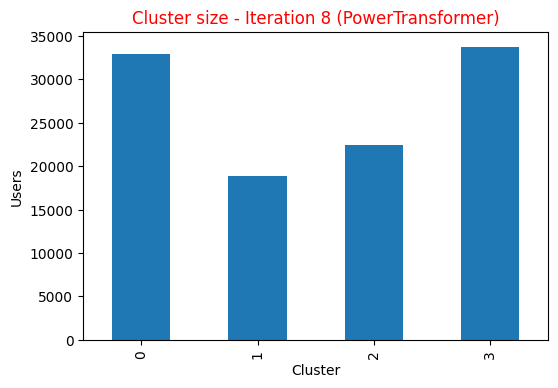

In [0]:
import matplotlib.pyplot as plt
plt.figure(figsize = (6,4))

base_iter8['cluster'].value_counts().sort_index().plot(kind= 'bar')
plt.title('Cluster size - Iteration 8 (PowerTransformer)', color = 'red')
plt.xlabel('Cluster')
plt.ylabel('Users')
plt.show()

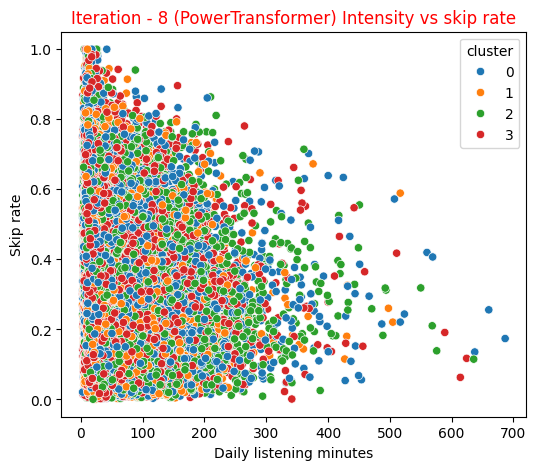

In [0]:
# scatter plot (No PCA)

# intensity vs skip
import seaborn as sns

plt.figure(figsize= (6,5))
sns.scatterplot(
    data = base_iter8,
    x = 'daily_listening_minutes',
    y = 'skip_rate',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 8 (PowerTransformer) Intensity vs skip rate', color = 'red')
plt.xlabel('Daily listening minutes')
plt.ylabel('Skip rate')
plt.show()

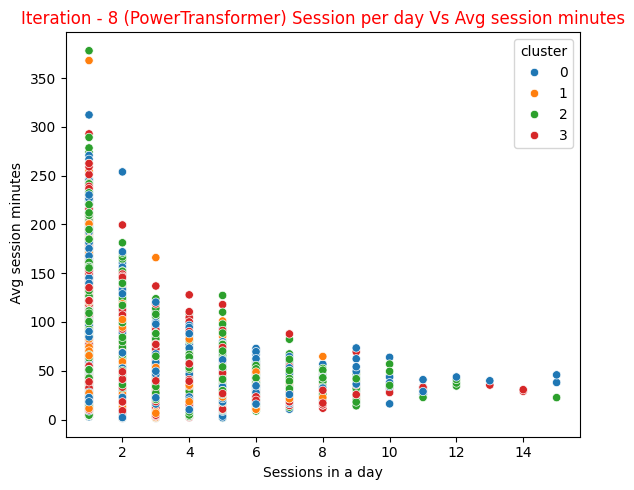

In [0]:
# frequency vs Session depth

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter8,
    x = 'sessions_per_day',
    y= 'avg_session_minutes',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('Iteration - 8 (PowerTransformer) Session per day Vs Avg session minutes', color = 'red')
plt.xlabel('Sessions in a day')
plt.ylabel(' Avg session minutes')
plt.tight_layout()
plt.show()

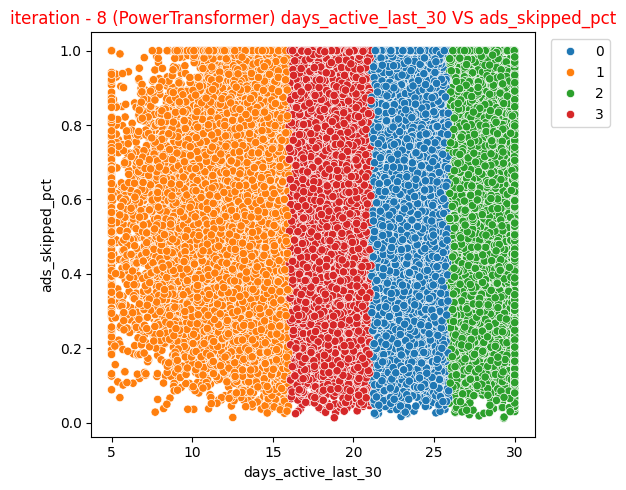

In [0]:
# consistance vs Ad friction

plt.figure(figsize= (6,5))

sns.scatterplot(
    data = base_iter8,
    x = 'days_active_last_30',
    y= 'ads_skipped_pct',
    hue = 'cluster',
    palette = 'tab10'
)

plt.title('iteration - 8 (PowerTransformer) days_active_last_30 VS ads_skipped_pct', color = 'red')
plt.legend(bbox_to_anchor = (1.02, 1))
plt.tight_layout()
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

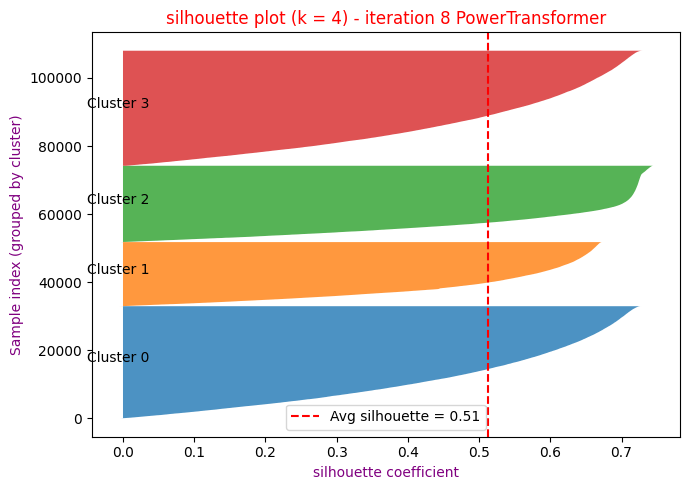

In [0]:
# silhouette Plot

sil_values_8 = silhouette_samples(X8, labels8)
sil_avg_8 = silhouette_score(X8, labels8)
plt.figure(figsize= (7,5))

y_lower = 0

vals0 = sil_values_8[labels8 == 0]
vals0.sort()
size0 = vals0.shape[0]

y_upper = y_lower + size0

plt.fill_betweenx(
    np.arange(y_lower, y_upper),    # vertical span
    0,                              # left boundary (silhoutte = 0)
    vals0,                          # right boundary (actual silhoutte values)
    alpha = 0.8
)
plt.text(
    -0.05,
    y_lower + 0.5 * size0,  # slightly left of zero
    'Cluster 0'             # vertically centered
)

y_lower = y_upper

# Cluster 1
vals1 = sil_values_8[labels8==1]
vals1.sort()
size1 = vals1.shape[0]

y_upper = y_lower + size1

plt.fill_betweenx(
    np.arange(y_lower, y_upper),
    0,
    vals1,
    alpha = 0.8
    )
plt.text(-0.05,
         y_lower + 0.5 * size1, 'Cluster 1')

y_lower = y_upper

# cluster 2
vals2 = sil_values_8[labels8 == 2]
vals2.sort()

size2 = vals2.shape[0]
y_upper = y_lower + size2
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals2, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size2, 'Cluster 2')

y_lower = y_upper

# cluster 3
vals3 = sil_values_8[labels8 == 3]
vals3.sort()
size3 = vals3.shape[0]
y_upper = y_lower + size3
plt.fill_betweenx(np.arange(y_lower, y_upper), 0, vals3, alpha = 0.8)
plt.text(-0.05, y_lower + 0.5 * size3, 'Cluster 3')

y_lower = y_upper

plt.axvline(
    x= sil_avg_8,
    color = 'red',
    linestyle = '--',
    label =f"Avg silhouette = {sil_avg_8:.2f}"
)

plt.title('silhouette plot (k = 4) - iteration 8 PowerTransformer', color = 'red')
plt.xlabel('silhouette coefficient', color = 'purple')
plt.ylabel('Sample index (grouped by cluster)', color = 'purple')
plt.legend()
plt.tight_layout()
plt.show